In [699]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
#SettingWithCopyWarning ignore

In [592]:
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSUF-SQyZqxD4pzE50BbW8fGo-8UmAf65BXSpJTaobvBFdzkQoEcw7mBab_Clf2V9hvEWZpxxIh2OzX/pub?output=csv')

In [593]:
df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,YOUNG SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium


In [594]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              264836 non-null  int64  
 1   STORE_NBR         264836 non-null  int64  
 2   LYLTY_CARD_NBR    264836 non-null  int64  
 3   TXN_ID            264836 non-null  int64  
 4   PROD_NBR          264836 non-null  int64  
 5   PROD_NAME         264836 non-null  object 
 6   PROD_QTY          264836 non-null  int64  
 7   TOT_SALES         264836 non-null  float64
 8   LIFESTAGE         264836 non-null  object 
 9   PREMIUM_CUSTOMER  264836 non-null  object 
dtypes: float64(1), int64(6), object(3)
memory usage: 20.2+ MB


In [595]:
df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [596]:
# missing values

df.isnull().sum()


,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [597]:
#find duplicate and remove


df.duplicated().sum()


df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

In [598]:

if 'DATE' in df.columns:
    if pd.api.types.is_numeric_dtype(df['DATE']):

        df['DATE'] = pd.to_datetime(df['DATE'], unit='D', origin='1899-12-30', errors='coerce')
        print(" 'DATE' column successfully converted to datetime.")

else:
    print(" 'DATE' column not found in the DataFrame.")


df['DATE'].head(20)


 'DATE' column successfully converted to datetime.


,DATE
0,2018-10-17
1,2019-05-14
2,2019-05-20
3,2018-08-17
4,2018-08-18
5,2019-05-19
6,2019-05-16
7,2019-05-16
8,2018-08-20
9,2018-08-18


In [599]:
df['DATE'].min()


Timestamp('2018-07-01 00:00:00')

In [600]:
start_date = df['DATE'].min()
date_range = np.arange(start_date, start_date + np.timedelta64(365, 'D'), dtype='datetime64[D]')

date_range

array(['2018-07-01', '2018-07-02', '2018-07-03', '2018-07-04',
       '2018-07-05', '2018-07-06', '2018-07-07', '2018-07-08',
       '2018-07-09', '2018-07-10', '2018-07-11', '2018-07-12',
       '2018-07-13', '2018-07-14', '2018-07-15', '2018-07-16',
       '2018-07-17', '2018-07-18', '2018-07-19', '2018-07-20',
       '2018-07-21', '2018-07-22', '2018-07-23', '2018-07-24',
       '2018-07-25', '2018-07-26', '2018-07-27', '2018-07-28',
       '2018-07-29', '2018-07-30', '2018-07-31', '2018-08-01',
       '2018-08-02', '2018-08-03', '2018-08-04', '2018-08-05',
       '2018-08-06', '2018-08-07', '2018-08-08', '2018-08-09',
       '2018-08-10', '2018-08-11', '2018-08-12', '2018-08-13',
       '2018-08-14', '2018-08-15', '2018-08-16', '2018-08-17',
       '2018-08-18', '2018-08-19', '2018-08-20', '2018-08-21',
       '2018-08-22', '2018-08-23', '2018-08-24', '2018-08-25',
       '2018-08-26', '2018-08-27', '2018-08-28', '2018-08-29',
       '2018-08-30', '2018-08-31', '2018-09-01', '2018-

In [601]:
date_range[~np.isin(date_range, df['DATE'].unique())]

array(['2018-12-25'], dtype='datetime64[D]')

In [602]:
#find TOT_SALES for DATE '2018-12-25'

tot_sales_20181225 = df[df['DATE'] == '2018-12-25']['TOT_SALES'].sum()
print(f"TOT_SALES for 2018-12-25: {tot_sales_20181225}")


TOT_SALES for 2018-12-25: 0.0


In [603]:
print(df['PROD_NAME'])


0           Natural Chip        Compny SeaSalt175g
1                         CCs Nacho Cheese    175g
2           Smiths Crinkle Cut  Chips Chicken 170g
3           Smiths Chip Thinly  S/Cream&Onion 175g
4         Kettle Tortilla ChpsHny&Jlpno Chili 150g
                            ...                   
264831     Kettle Sweet Chilli And Sour Cream 175g
264832               Tostitos Splash Of  Lime 175g
264833                    Doritos Mexicana    170g
264834     Doritos Corn Chip Mexican Jalapeno 150g
264835               Tostitos Splash Of  Lime 175g
Name: PROD_NAME, Length: 264835, dtype: object


In [604]:
# remove symbols in PROD_NAME such as &, /, \ , ", lower case

import re

def clean_product_name(name):
  if isinstance(name, str):
    name = re.sub(r'[&/\\"]', '', name)
    name = name.lower()
  return name

df['PROD_NAME'] = df['PROD_NAME'].apply(clean_product_name)
print(df['PROD_NAME'])


0          natural chip        compny seasalt175g
1                        ccs nacho cheese    175g
2          smiths crinkle cut  chips chicken 170g
3            smiths chip thinly  screamonion 175g
4         kettle tortilla chpshnyjlpno chili 150g
                           ...                   
264831    kettle sweet chilli and sour cream 175g
264832              tostitos splash of  lime 175g
264833                   doritos mexicana    170g
264834    doritos corn chip mexican jalapeno 150g
264835              tostitos splash of  lime 175g
Name: PROD_NAME, Length: 264835, dtype: object


In [605]:
# the product with the maximum total sales
product_sales = df.groupby('PROD_NAME')['TOT_SALES'].sum()

max_sales_product = product_sales.idxmax()
max_sales_value = product_sales.max()

print(f"The product with the highest total sales is '{max_sales_product}' with a total of {max_sales_value} sales.")


The product with the highest total sales is 'dorito corn chp     supreme 380g' with a total of 40352.0 sales.


In [606]:
# which STORE_NBR generates highest sales

store_sales = df.groupby('STORE_NBR')['TOT_SALES'].sum()

max_sales_store = store_sales.idxmax()
max_sales_store_value = store_sales.max()

print(f"The store with the highest total sales is '{max_sales_store}' with a total of {max_sales_store_value} sales.")


The store with the highest total sales is '226' with a total of 18905.45 sales.


In [607]:
# top performers

top_products = product_sales.sort_values(ascending=False).head(10)
print("\nTop 10 Performing Products:")
top_products



Top 10 Performing Products:


,TOT_SALES
PROD_NAME,
dorito corn chp supreme 380g,40352.0
smiths crnkle chip orgnl big bag 380g,36367.6
smiths crinkle chips salt vinegar 330g,34804.2
kettle mozzarella basil pesto 175g,34457.4
smiths crinkle original 330g,34302.6
cheezels cheese 330g,34296.9
doritos cheese supreme 330g,33390.6
kettle sweet chilli and sour cream 175g,33031.8
kettle original 175g,32740.2


In [608]:
# underperforming products

total_sales_quantile = product_sales.quantile(0.1)
underperforming_products = product_sales[product_sales <= total_sales_quantile]

print("\nUnderperforming Products (bottom 10% by total sales):")
underperforming_products



Underperforming Products (bottom 10% by total sales):


,TOT_SALES
PROD_NAME,
snbts whlgrn crisps cheddrmstrd 90g,5076.2
sunbites whlegrn crisps frchonin 90g,4600.2
woolworths cheese rings 190g,5169.6
woolworths medium salsa 300g,4050.0
woolworths mild salsa 300g,4234.5
ww crinkle cut chicken 175g,4702.2
ww crinkle cut original 175g,4532.2
ww dstyle chip sea salt 200g,5249.7
ww original corn chips 200g,5367.5


In [609]:
# extract the brand name PROD_NAME

def extract_brand(prod_name):
    return prod_name.split()[0]

df['BRAND'] = df['PROD_NAME'].apply(extract_brand)
print(df[['PROD_NAME', 'BRAND']])
df

                                      PROD_NAME     BRAND
0        natural chip        compny seasalt175g   natural
1                      ccs nacho cheese    175g       ccs
2        smiths crinkle cut  chips chicken 170g    smiths
3          smiths chip thinly  screamonion 175g    smiths
4       kettle tortilla chpshnyjlpno chili 150g    kettle
...                                         ...       ...
264831  kettle sweet chilli and sour cream 175g    kettle
264832            tostitos splash of  lime 175g  tostitos
264833                 doritos mexicana    170g   doritos
264834  doritos corn chip mexican jalapeno 150g   doritos
264835            tostitos splash of  lime 175g  tostitos

[264835 rows x 2 columns]


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,natural
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,YOUNG SINGLES/COUPLES,Budget,ccs
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,smiths
3,2018-08-17,2,2373,974,69,smiths chip thinly screamonion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,smiths
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshnyjlpno chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,kettle
...,...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,kettle sweet chilli and sour cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium,kettle
264832,2018-08-13,272,272358,270154,74,tostitos splash of lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium,tostitos
264833,2018-11-06,272,272379,270187,51,doritos mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium,doritos
264834,2018-12-27,272,272379,270188,42,doritos corn chip mexican jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium,doritos


In [610]:
# unique brand names

unique_brands = df['BRAND'].unique()
unique_brands


array(['natural', 'ccs', 'smiths', 'kettle', 'old', 'grain', 'doritos',
       'twisties', 'ww', 'thins', 'burger', 'ncc', 'cheezels', 'infzns',
       'red', 'pringles', 'dorito', 'infuzions', 'smith', 'grnwves',
       'tyrrells', 'cobs', 'woolworths', 'french', 'rrd', 'tostitos',
       'cheetos', 'snbts', 'sunbites'], dtype=object)

In [611]:
# prompt: print all Brand names

print(df['BRAND'].unique()) # Change 'BRAND' to 'Brand'


['natural' 'ccs' 'smiths' 'kettle' 'old' 'grain' 'doritos' 'twisties' 'ww'
 'thins' 'burger' 'ncc' 'cheezels' 'infzns' 'red' 'pringles' 'dorito'
 'infuzions' 'smith' 'grnwves' 'tyrrells' 'cobs' 'woolworths' 'french'
 'rrd' 'tostitos' 'cheetos' 'snbts' 'sunbites']


In [612]:
df['BRAND'] = df['BRAND'].replace({'ww': 'woolworths', 'snbts': 'sunbites', 'infzns' : 'infuzions'})
df['BRAND'].unique()

array(['natural', 'ccs', 'smiths', 'kettle', 'old', 'grain', 'doritos',
       'twisties', 'woolworths', 'thins', 'burger', 'ncc', 'cheezels',
       'infuzions', 'red', 'pringles', 'dorito', 'smith', 'grnwves',
       'tyrrells', 'cobs', 'french', 'rrd', 'tostitos', 'cheetos',
       'sunbites'], dtype=object)

In [613]:
# Remove salsa products
df = df[~df['PROD_NAME'].str.contains('salsa', na=False, case=False)]
df


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,natural
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,YOUNG SINGLES/COUPLES,Budget,ccs
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,smiths
3,2018-08-17,2,2373,974,69,smiths chip thinly screamonion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,smiths
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshnyjlpno chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,kettle
...,...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,kettle sweet chilli and sour cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium,kettle
264832,2018-08-13,272,272358,270154,74,tostitos splash of lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium,tostitos
264833,2018-11-06,272,272379,270187,51,doritos mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium,doritos
264834,2018-12-27,272,272379,270188,42,doritos corn chip mexican jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium,doritos


In [614]:
df['PROD_NAME'].value_counts()

,count
PROD_NAME,
kettle mozzarella basil pesto 175g,3304
kettle tortilla chpshnyjlpno chili 150g,3296
cobs popd swtchlli srcream chips 110g,3269
tyrrells crisps ched chives 165g,3268
cobs popd sea salt chips 110g,3265
...,...
sunbites whlegrn crisps frchonin 90g,1432
rrd pc sea salt 165g,1431
ncc sour cream garden chives 175g,1419


In [615]:
df['BRAND'].value_counts()

,count
BRAND,
kettle,41288
smiths,27389
pringles,25102
doritos,22041
infuzions,14201
thins,14075
rrd,11894
woolworths,11836
cobs,9693


In [616]:
# which LYLTY_CARD_NBR makes more sales


customer_sales = df.groupby('LYLTY_CARD_NBR')['TOT_SALES'].sum()

max_sales_customer = customer_sales.idxmax()
max_customer_sales_value = customer_sales.max()

print(f"The customer with the highest total sales is '{max_sales_customer}' with a total of {max_customer_sales_value} sales.")


The customer with the highest total sales is '226000' with a total of 1300.0 sales.


In [617]:
#LIFESTAGE for LYLTY_CARD_NBR '226000'

customer_lifstage = df[df['LYLTY_CARD_NBR'] == 226000]['LIFESTAGE'].iloc[0]
print(f"The LIFESTAGE for customer '226000' is: {customer_lifstage}")


The LIFESTAGE for customer '226000' is: OLDER FAMILIES


In [618]:
# what is PREMIUM_CUSTOMER for LYLTY_CARD_NBR '226000'

customer_premium = df[df['LYLTY_CARD_NBR'] == 226000]['PREMIUM_CUSTOMER'].iloc[0]
print(f"The PREMIUM_CUSTOMER status for customer '226000' is: {customer_premium}")


The PREMIUM_CUSTOMER status for customer '226000' is: Premium


In [619]:
# group customers by PREMIUM_CUSTOMER column and count descending

customer_premium_counts = df.groupby('PREMIUM_CUSTOMER')['LYLTY_CARD_NBR'].count().sort_values(ascending=False)
customer_premium_counts


,LYLTY_CARD_NBR
PREMIUM_CUSTOMER,
Mainstream,95043
Budget,86762
Premium,64936


In [620]:
# group customers by LIFESTAGE descending

customer_lifstage_sales = df.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values(ascending=False)

customer_lifstage_sales


,TOT_SALES
LIFESTAGE,
OLDER SINGLES/COUPLES,376013.65
RETIREES,342381.90
OLDER FAMILIES,329819.90
YOUNG FAMILIES,294627.90
YOUNG SINGLES/COUPLES,243762.90
MIDAGE SINGLES/COUPLES,172517.50
NEW FAMILIES,47347.95


In [621]:
# Average Transaction Value (ATV)

# Calculate Average Transaction Value (ATV)
atv = df['TOT_SALES'].sum() / df['TXN_ID'].nunique()
print(f"\nAverage Transaction Value (ATV): {atv}")



Average Transaction Value (ATV): 7.36562748463856


In [700]:
df['PROD_NAME'] = df['PROD_NAME'].str.strip()
df['PROD_NAME'] = df['PROD_NAME'].str.replace('natural chip compny seasalt175g', 'natural chip compny seasalt 175g')
df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,SIZE,PRICE
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,natural,175g,3.00
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,YOUNG SINGLES/COUPLES,Budget,ccs,175g,2.10
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,smiths,170g,1.45
3,2018-08-17,2,2373,974,69,smiths chip thinly screamonion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,smiths,175g,3.00
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshnyjlpno chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,kettle,150g,4.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,kettle sweet chilli and sour cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium,kettle,175g,5.40
264832,2018-08-13,272,272358,270154,74,tostitos splash of lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium,tostitos,175g,4.40
264833,2018-11-06,272,272379,270187,51,doritos mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium,doritos,170g,4.40
264834,2018-12-27,272,272379,270188,42,doritos corn chip mexican jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium,doritos,150g,3.90


In [701]:
# extract the package size from PROD_NAME column in separate column

import re

def extract_size(prod_name):
  match = re.search(r'(\d+g)', prod_name, re.IGNORECASE)
  if match:
    return match.group(1)
  else:
    return None

df['SIZE'] = df['PROD_NAME'].apply(extract_size)
print(df[['PROD_NAME', 'SIZE']])


                                      PROD_NAME  SIZE
0        natural chip        compny seasalt175g  175g
1                      ccs nacho cheese    175g  175g
2        smiths crinkle cut  chips chicken 170g  170g
3          smiths chip thinly  screamonion 175g  175g
4       kettle tortilla chpshnyjlpno chili 150g  150g
...                                         ...   ...
264831  kettle sweet chilli and sour cream 175g  175g
264832            tostitos splash of  lime 175g  175g
264833                 doritos mexicana    170g  170g
264834  doritos corn chip mexican jalapeno 150g  150g
264835            tostitos splash of  lime 175g  175g

[246741 rows x 2 columns]


In [624]:
df.sample(20)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,SIZE
167151,2018-10-08,213,213245,213511,20,doritos cheese supreme 330g,2,11.4,RETIREES,Mainstream,doritos,330g
38177,2019-03-26,69,69094,66426,77,doritos corn chips nacho cheese 170g,2,8.8,OLDER FAMILIES,Budget,doritos,170g
7949,2018-07-18,63,63071,59804,62,pringles mystery flavour 134g,2,7.4,MIDAGE SINGLES/COUPLES,Mainstream,pringles,134g
163059,2019-06-05,157,157175,159508,114,kettle sensations siracha lime 150g,2,9.2,RETIREES,Mainstream,kettle,150g
255234,2019-05-21,228,228060,229926,34,pringles slt vingar 134g,2,7.4,YOUNG SINGLES/COUPLES,Mainstream,pringles,134g
202800,2019-06-21,248,248027,250219,19,smiths crinkle cut snagsauce 150g,2,5.2,YOUNG FAMILIES,Budget,smiths,150g
109229,2019-01-27,137,137238,140330,43,smith crinkle cut bolognese 150g,2,5.2,OLDER SINGLES/COUPLES,Mainstream,smith,150g
1621,2019-01-15,84,84350,84079,33,cobs popd swtchlli srcream chips 110g,2,7.6,MIDAGE SINGLES/COUPLES,Budget,cobs,110g
150219,2019-06-14,271,271119,268902,33,cobs popd swtchlli srcream chips 110g,2,7.6,RETIREES,Budget,cobs,110g
33059,2018-09-05,4,4086,3034,31,infzns crn crnchers tangy gcamole 110g,2,7.6,OLDER FAMILIES,Budget,infuzions,110g


In [702]:
# calculate the price for each PROD_NAME


df['PRICE'] = df['TOT_SALES'] / df['PROD_QTY']

df


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,SIZE,PRICE
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,natural,175g,3.00
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,YOUNG SINGLES/COUPLES,Budget,ccs,175g,2.10
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,smiths,170g,1.45
3,2018-08-17,2,2373,974,69,smiths chip thinly screamonion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,smiths,175g,3.00
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshnyjlpno chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,kettle,150g,4.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,kettle sweet chilli and sour cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium,kettle,175g,5.40
264832,2018-08-13,272,272358,270154,74,tostitos splash of lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium,tostitos,175g,4.40
264833,2018-11-06,272,272379,270187,51,doritos mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium,doritos,170g,4.40
264834,2018-12-27,272,272379,270188,42,doritos corn chip mexican jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium,doritos,150g,3.90


In [626]:
# the most popular SIZE and how much sales it has


size_sales = df.groupby('SIZE')['TOT_SALES'].sum()

most_popular_size = size_sales.idxmax()

sales_of_most_popular_size = size_sales.max()

print(f"The most popular size is '{most_popular_size}' with total sales of {sales_of_most_popular_size}")


The most popular size is '175g' with total sales of 485431.4


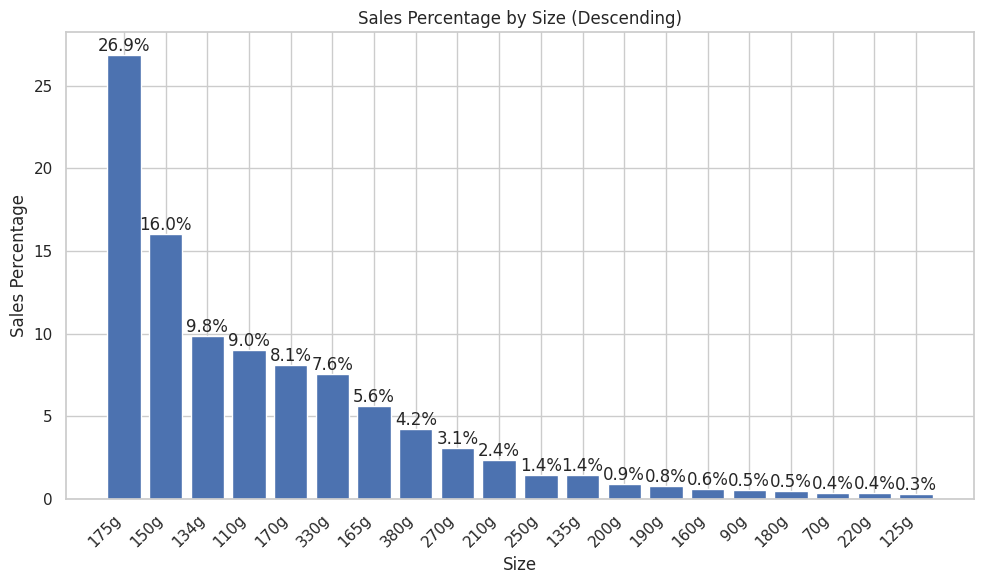

In [656]:
#group by SIZE and count, plot to demonstrate sales percentage for each size descending include percentage number

size_sales = df.groupby('SIZE')['TOT_SALES'].sum()
total_sales = size_sales.sum()
size_sales_percentage = (size_sales / total_sales) * 100
size_sales_percentage_sorted = size_sales_percentage.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(size_sales_percentage_sorted.index, size_sales_percentage_sorted.values)

for bar, percentage in zip(bars, size_sales_percentage_sorted.values):
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval, f'{percentage:.1f}%', ha='center', va='bottom')

plt.xlabel('Size')
plt.ylabel('Sales Percentage')
plt.title('Sales Percentage by Size (Descending)')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


In [628]:
# which store number highest number of PREMIUM_CUSTOMER is Budget count how many Budget
premium_customer_counts = df[df['PREMIUM_CUSTOMER'] == 'Budget'].groupby('STORE_NBR')['PREMIUM_CUSTOMER'].count()
store_with_most_budget_customers = premium_customer_counts.idxmax()
budget_customer_count = premium_customer_counts.max()

print(f"The store with the highest number of 'Budget' PREMIUM_CUSTOMERS is store number {store_with_most_budget_customers} with {budget_customer_count} customers.")


The store with the highest number of 'Budget' PREMIUM_CUSTOMERS is store number 226 with 714 customers.


In [629]:
# which store number highest number of PREMIUM_CUSTOMER is Mainstream count how many Mainstream

premium_customer_counts = df[df['PREMIUM_CUSTOMER'] == 'Mainstream'].groupby('STORE_NBR')['PREMIUM_CUSTOMER'].count()
store_with_most_mainstream_customers = premium_customer_counts.idxmax()
mainstream_customer_count = premium_customer_counts.max()

print(f"The store with the highest number of 'Mainstream' PREMIUM_CUSTOMERS is store number {store_with_most_mainstream_customers} with {mainstream_customer_count} customers.")


The store with the highest number of 'Mainstream' PREMIUM_CUSTOMERS is store number 226 with 749 customers.


In [630]:
# which store number highest number of PREMIUM_CUSTOMER is Premium count how many Premium

premium_customer_counts = df[df['PREMIUM_CUSTOMER'] == 'Premium'].groupby('STORE_NBR')['PREMIUM_CUSTOMER'].count()
store_with_most_premium_customers = premium_customer_counts.idxmax()
premium_customer_count = premium_customer_counts.max()

print(f"The store with the highest number of 'Premium' PREMIUM_CUSTOMERS is store number {store_with_most_premium_customers} with {premium_customer_count} customers.")


The store with the highest number of 'Premium' PREMIUM_CUSTOMERS is store number 165 with 566 customers.


In [631]:
#  Group by 'PREMIUM_CUSTOMER' and 'LIFESTAGE' and count the occurrences
lifstage_by_premium = df.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE'])['LYLTY_CARD_NBR'].count().unstack()
lifstage_by_premium


LIFESTAGE,MIDAGE SINGLES/COUPLES,NEW FAMILIES,OLDER FAMILIES,OLDER SINGLES/COUPLES,RETIREES,YOUNG FAMILIES,YOUNG SINGLES/COUPLES
PREMIUM_CUSTOMER,,,,,,,
Budget,4690,2824,21514,17172,14225,17763,8574
Mainstream,11095,2185,13241,17061,19970,11947,19544
Premium,7612,1488,10405,16559,12236,10784,5852


In [657]:
#  which  PROD_NAME has more sales for Premium' PREMIUM_CUSTOMERS

premium_sales = df[df['PREMIUM_CUSTOMER'] == 'Premium'].groupby('PROD_NAME')['TOT_SALES'].sum()
product_with_highest_premium_sales = premium_sales.idxmax()
highest_premium_sales_value = premium_sales.max()

print(f"The product with the highest sales among premium customers is '{product_with_highest_premium_sales}' with total sales of {highest_premium_sales_value}.")


The product with the highest sales among premium customers is 'dorito corn chp     supreme 380g' with total sales of 11917.75.


In [633]:
# group by LIFESTAGE and identify product preferences, highlight top 3 product for each Lifestage

top3_products_by_lifstage = df.groupby('LIFESTAGE')['PROD_NAME'].value_counts().groupby('LIFESTAGE').head(3)
print("\nTop 3 Products for each Lifestage:\n", top3_products_by_lifstage)



Top 3 Products for each Lifestage:
 LIFESTAGE               PROD_NAME                              
MIDAGE SINGLES/COUPLES  infzns crn crnchers tangy gcamole 110g     344
                        cheezels cheese 330g                       335
                        twisties chicken270g                       335
NEW FAMILIES            kettle honey soy    chicken 175g           107
                        grain waves         sweet chilli 210g      104
                        cobs popd sour crm  chives chips 110g      102
OLDER FAMILIES          smiths crinkle chips salt  vinegar 330g    589
                        thins potato chips  hot  spicy 175g        579
                        infzns crn crnchers tangy gcamole 110g     570
OLDER SINGLES/COUPLES   kettle 135g swt pot sea salt               740
                        cobs popd sea salt  chips 110g             727
                        thins chips seasonedchicken 175g           719
RETIREES                thins chips light  tang

In [634]:
# Budget-conscious families

budget_families = df[(df['PREMIUM_CUSTOMER'] == 'Budget') & (df['LIFESTAGE'].isin(['YOUNG FAMILIES', 'OLDER FAMILIES']))]

top_products_budget_families = budget_families['PROD_NAME'].value_counts().head(10)
print("Top 10 products purchased by budget-conscious families:\n", top_products_budget_families)


avg_spend_budget_families = budget_families['TOT_SALES'].mean()
print(f"\nAverage spend of budget-conscious families: {avg_spend_budget_families}")


Top 10 products purchased by budget-conscious families:
 PROD_NAME
smiths crinkle chips salt  vinegar 330g    515
doritos corn chips  cheese supreme 170g    510
cheezels cheese 330g                       502
pringles sourcream  onion 134g             500
kettle mozzarella   basil  pesto 175g      498
kettle tortilla chpshnyjlpno chili 150g    497
thins potato chips  hot  spicy 175g        495
grain waves         sweet chilli 210g      492
smiths crinkle      original 330g          491
twisties cheese     burger 250g            489
Name: count, dtype: int64

Average spend of budget-conscious families: 7.296425388904448


In [635]:
# the most frequent pack sizes purchased by budget-conscious families
pack_sizes_budget_families = budget_families['SIZE'].value_counts()
print("\nMost frequent pack sizes purchased by budget-conscious families:\n", pack_sizes_budget_families)



Most frequent pack sizes purchased by budget-conscious families:
 SIZE
175g    10729
150g     6450
134g     3670
110g     3291
170g     3270
165g     2524
330g     1984
210g      945
270g      942
380g      941
200g      817
90g       559
190g      554
160g      534
250g      489
135g      480
180g      291
220g      283
70g       264
125g      260
Name: count, dtype: int64


In [636]:
# prompt: Mainstream Budget and premium customers purchase frequency
purchase_frequency = df.groupby(['PREMIUM_CUSTOMER', 'LYLTY_CARD_NBR'])['TXN_ID'].count().reset_index()
purchase_frequency = purchase_frequency.groupby('PREMIUM_CUSTOMER')['TXN_ID'].mean().reset_index()
purchase_frequency = purchase_frequency.rename(columns={'TXN_ID': 'Average Purchase Frequency'})
purchase_frequency


,PREMIUM_CUSTOMER,Average Purchase Frequency
0,Budget,3.614180
1,Mainstream,3.307684
2,Premium,3.500970


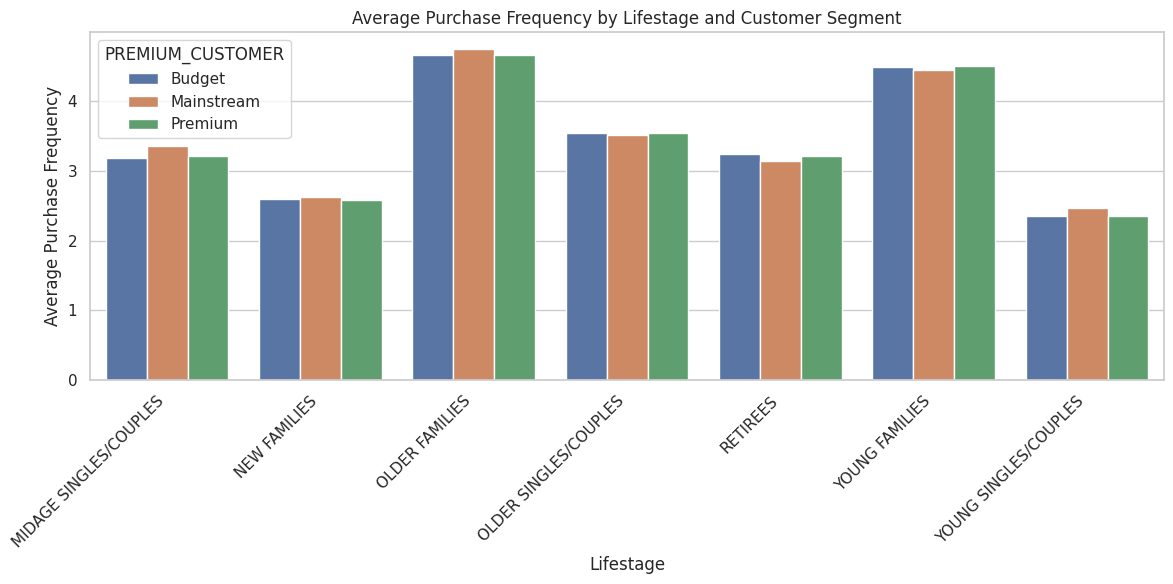

In [637]:
# Comparing purchase frequency across different LIFESTAGE groups within each segment


purchase_frequency = df.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE', 'LYLTY_CARD_NBR'])['TXN_ID'].count().reset_index()
average_purchase_frequency = purchase_frequency.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE'])['TXN_ID'].mean().reset_index()


plt.figure(figsize=(12, 6))
sns.barplot(x='LIFESTAGE', y='TXN_ID', hue='PREMIUM_CUSTOMER', data=average_purchase_frequency)
plt.xlabel('Lifestage')
plt.ylabel('Average Purchase Frequency')
plt.title('Average Purchase Frequency by Lifestage and Customer Segment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


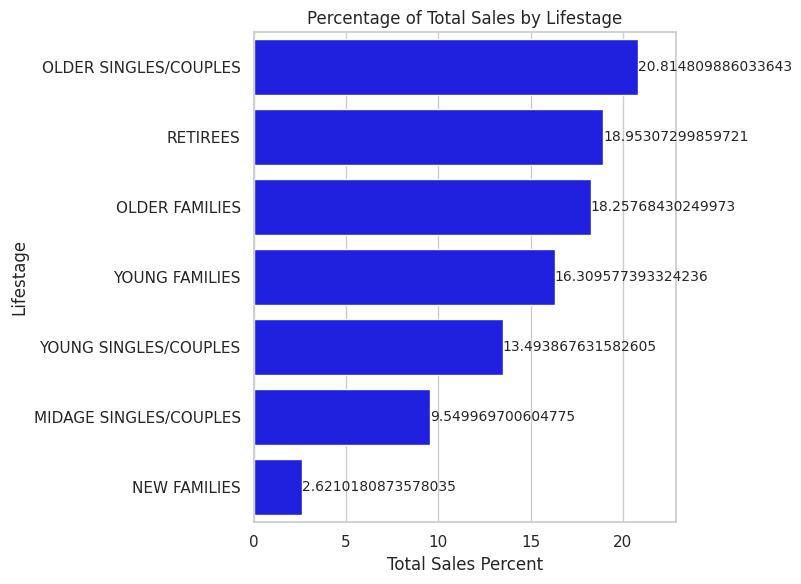

In [638]:

lt = df.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values(ascending=False)

lt = (lt / lt.sum()) * 100

plt.figure(figsize=(8, 6))
sns.barplot(x=lt.values, y=lt.index, color='blue')
for index, value in enumerate(lt.values):
    plt.text(value, index, str(value), fontsize=10, ha='left', va='center')
plt.title('Percentage of Total Sales by Lifestage')
plt.xlabel('Total Sales Percent')
plt.ylabel('Lifestage')
plt.xlim(0, max(lt.values) * 1.1)
plt.tight_layout()
plt.show()

In [639]:
pt=df.groupby(['PREMIUM_CUSTOMER'])['TOT_SALES'].sum().sort_values(ascending=False)
pt = np.round((pt/pt.sum())*100,2)
pt

,TOT_SALES
PREMIUM_CUSTOMER,
Mainstream,38.80
Budget,34.95
Premium,26.25


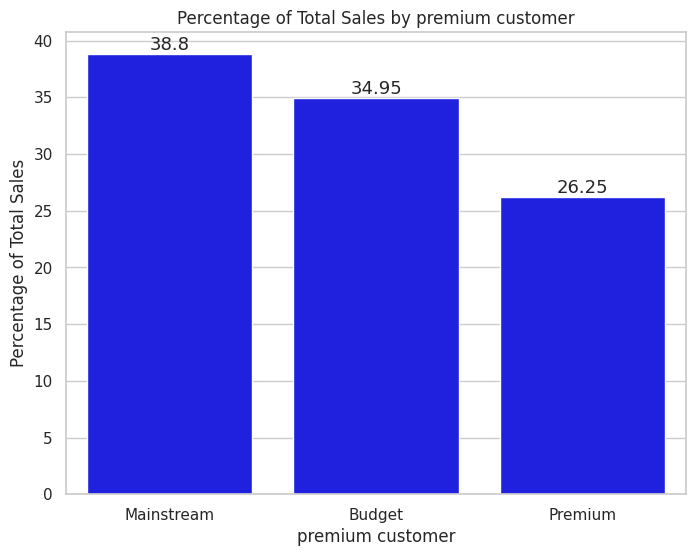

In [640]:
plt.figure(figsize=(8, 6))
sns.barplot(y=pt.values, x=pt.index, color='blue')
for i in range(len(pt)):
    plt.text(i, pt.values[i], str(pt.values[i]), ha='center', va='bottom',fontsize=13)
plt.title('Percentage of Total Sales by premium customer')
plt.xlabel('premium customer')
plt.ylabel('Percentage of Total Sales')
plt.show()

In [641]:
lpt=df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
lpt.TOT_SALES = np.round((lpt.TOT_SALES/lpt.TOT_SALES.sum())*100,2)
lpt

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
0,MIDAGE SINGLES/COUPLES,Budget,1.85
1,MIDAGE SINGLES/COUPLES,Mainstream,4.69
2,MIDAGE SINGLES/COUPLES,Premium,3.01
3,NEW FAMILIES,Budget,1.14
4,NEW FAMILIES,Mainstream,0.88
5,NEW FAMILIES,Premium,0.60
6,OLDER FAMILIES,Budget,8.68
7,OLDER FAMILIES,Mainstream,5.34
8,OLDER FAMILIES,Premium,4.24
9,OLDER SINGLES/COUPLES,Budget,7.08


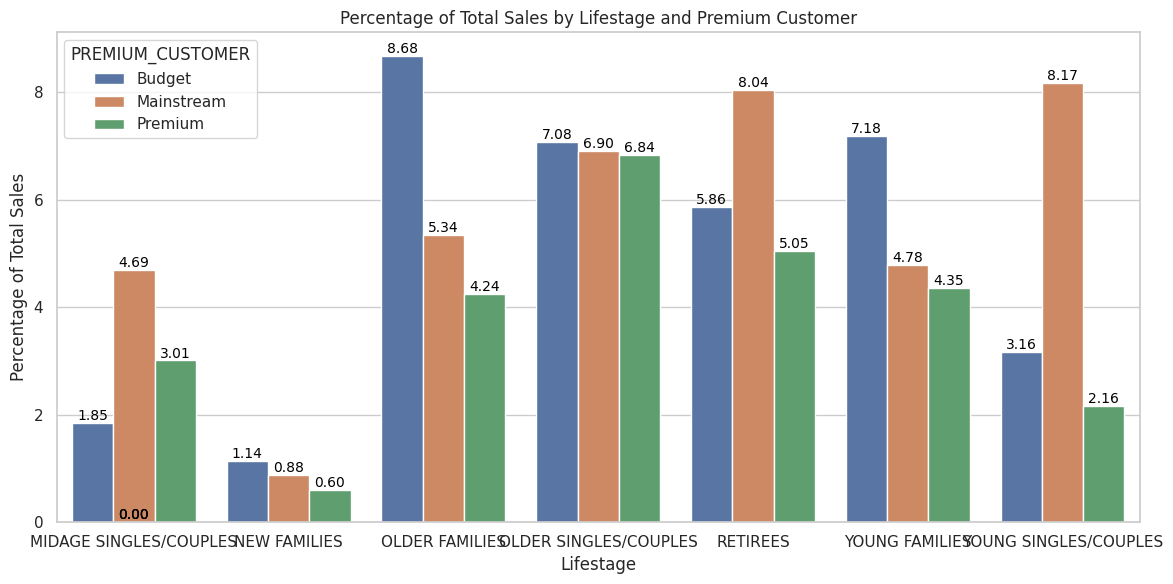

In [642]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=lpt, y='TOT_SALES', x='LIFESTAGE', hue='PREMIUM_CUSTOMER')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title('Percentage of Total Sales by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Percentage of Total Sales')
plt.tight_layout()

The top 3 customer segments responsible for sales are
older families with Budget membership, retirees with Mainstream membership, and  yound singles and couples with Mainstream membership

In [643]:
lpn=df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
lpn.LYLTY_CARD_NBR = np.round((lpn.LYLTY_CARD_NBR/lpn.LYLTY_CARD_NBR.sum())*100,2)
lpn

,LIFESTAGE,PREMIUM_CUSTOMER,LYLTY_CARD_NBR
0,MIDAGE SINGLES/COUPLES,Budget,2.07
1,MIDAGE SINGLES/COUPLES,Mainstream,4.63
2,MIDAGE SINGLES/COUPLES,Premium,3.32
3,NEW FAMILIES,Budget,1.52
4,NEW FAMILIES,Mainstream,1.16
5,NEW FAMILIES,Premium,0.81
6,OLDER FAMILIES,Budget,6.47
7,OLDER FAMILIES,Mainstream,3.91
8,OLDER FAMILIES,Premium,3.13
9,OLDER SINGLES/COUPLES,Budget,6.80


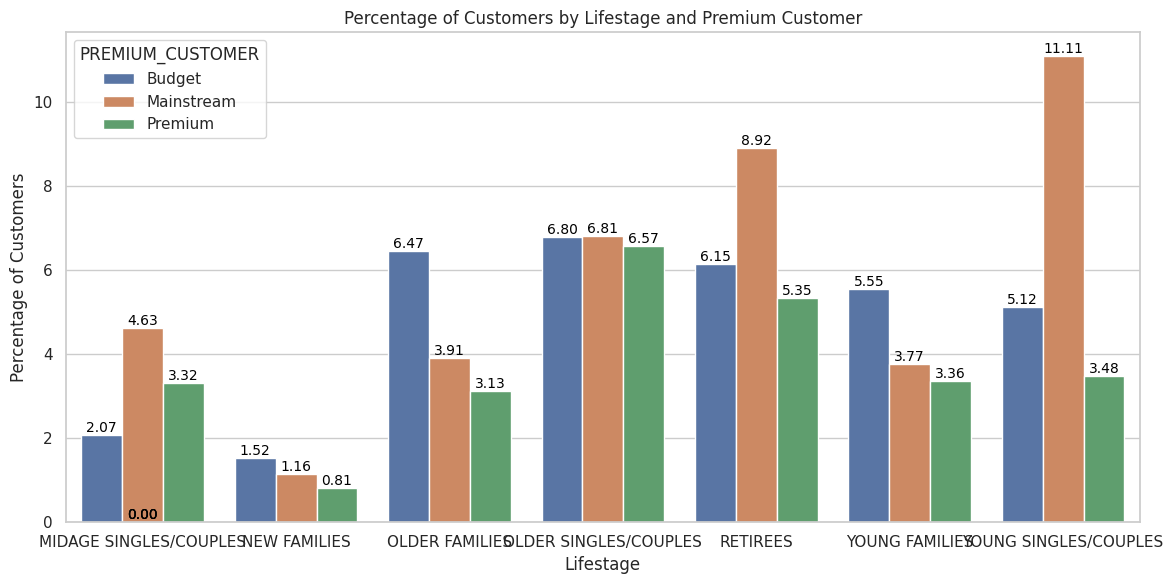

In [644]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=lpn, y='LYLTY_CARD_NBR', x='LIFESTAGE', hue='PREMIUM_CUSTOMER')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title('Percentage of Customers by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Percentage of Customers')
plt.tight_layout()

Yound singles/couples (11.11) with Mainstream membership and Retirees (8.92) represent a significant portion of the total customer base, indicating their importance for sales and marketing strategies.

In [645]:
lpu=df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg({'PROD_QTY': ['sum'], 'LYLTY_CARD_NBR':['nunique']})
lpu['unit_per_customer']=lpu[('PROD_QTY', 'sum')]/lpu[('LYLTY_CARD_NBR', 'nunique')]
lpu=lpu.reset_index()
lpu

,LIFESTAGE,PREMIUM_CUSTOMER,PROD_QTY,LYLTY_CARD_NBR,unit_per_customer
,,,sum,nunique,
0,MIDAGE SINGLES/COUPLES,Budget,8880,1474,6.024423
1,MIDAGE SINGLES/COUPLES,Mainstream,21213,3298,6.432080
2,MIDAGE SINGLES/COUPLES,Premium,14400,2369,6.078514
3,NEW FAMILIES,Budget,5241,1087,4.821527
4,NEW FAMILIES,Mainstream,4060,830,4.891566
5,NEW FAMILIES,Premium,2769,575,4.815652
6,OLDER FAMILIES,Budget,41853,4611,9.076773
7,OLDER FAMILIES,Mainstream,25804,2788,9.255380
8,OLDER FAMILIES,Premium,20639,2232,9.246864


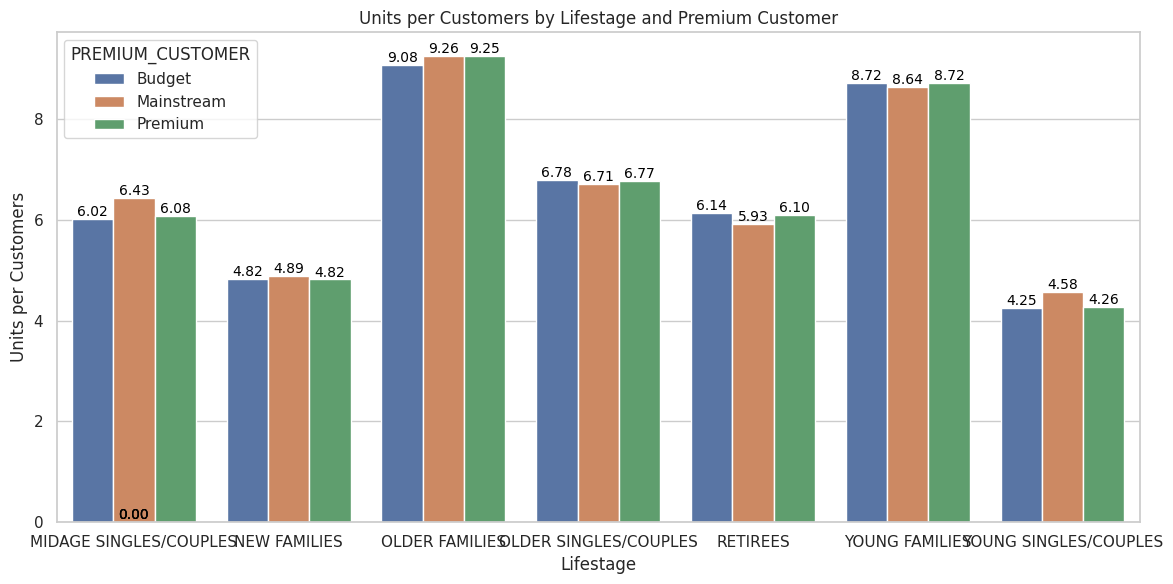

In [646]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=lpu, y='unit_per_customer', x='LIFESTAGE', hue='PREMIUM_CUSTOMER')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title('Units per Customers by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Units per Customers')
plt.tight_layout()

Older Families, in general, purchase the most chips per customer, Budget Older Families purchasing significantly more than Mainstream or Premium Older Families. Retirees and Young Singles/Couples with Mainstream memberships purchase similar numbers of chips per customer on average.

In [647]:
lpa=df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg({'TOT_SALES':['sum'],'PROD_QTY': ['sum'], })
lpa['average_price_per_unit_purchased']=lpa[('TOT_SALES', 'sum')]/lpa[('PROD_QTY', 'sum')]
lpa=lpa.reset_index()
lpa

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES,PROD_QTY,average_price_per_unit_purchased
,,,sum,sum,
0,MIDAGE SINGLES/COUPLES,Budget,33339.40,8880,3.754437
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25,21213,3.994449
2,MIDAGE SINGLES/COUPLES,Premium,54443.85,14400,3.780823
3,NEW FAMILIES,Budget,20607.45,5241,3.931969
4,NEW FAMILIES,Mainstream,15979.70,4060,3.935887
5,NEW FAMILIES,Premium,10760.80,2769,3.886168
6,OLDER FAMILIES,Budget,156863.75,41853,3.747969
7,OLDER FAMILIES,Mainstream,96413.55,25804,3.736380
8,OLDER FAMILIES,Premium,76542.60,20639,3.708639


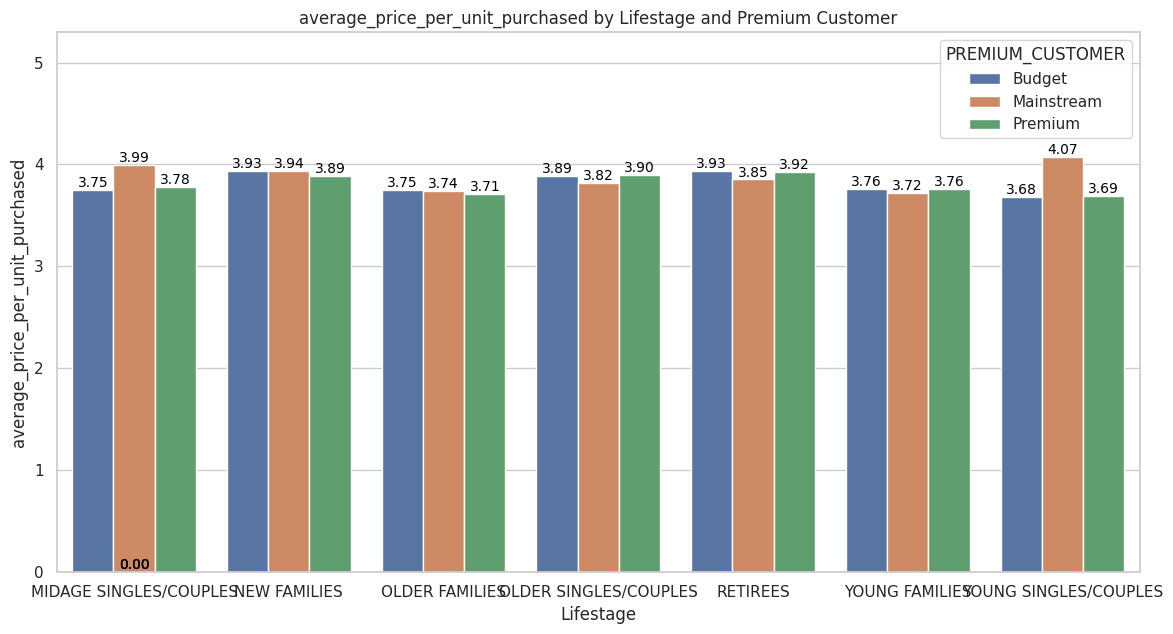

In [648]:
plt.figure(figsize=(12, 6.5))
ax = sns.barplot(data=lpa, y='average_price_per_unit_purchased', x='LIFESTAGE', hue='PREMIUM_CUSTOMER')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title('average_price_per_unit_purchased by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('average_price_per_unit_purchased')
plt.ylim(0, max(lpa.average_price_per_unit_purchased) * 1.3)
plt.tight_layout()

Midage singles/couples and Young singles/couples have the highest average price per unit purchased between premium categories.

In [703]:
# test significance of difference in young singles/coupless
young= df[df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES']
young['PRICE']=young['TOT_SALES']/young['PROD_QTY']
young

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,SIZE,PRICE
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,natural,175g,3.0
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,YOUNG SINGLES/COUPLES,Budget,ccs,175g,2.1
228460,2018-11-09,77,2330311,236755,90,tostitos smoked chipotle 175g,1,4.4,YOUNG SINGLES/COUPLES,Budget,tostitos,175g,4.4
228461,2019-05-16,1,1076,87,107,smiths crinkle cut french oniondip 150g,1,2.6,YOUNG SINGLES/COUPLES,Budget,smiths,150g,2.6
228462,2019-05-17,1,1165,192,12,natural chip co tmato hrbspce 175g,1,3.0,YOUNG SINGLES/COUPLES,Budget,natural,175g,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,kettle sweet chilli and sour cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium,kettle,175g,5.4
264832,2018-08-13,272,272358,270154,74,tostitos splash of lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium,tostitos,175g,4.4
264833,2018-11-06,272,272379,270187,51,doritos mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium,doritos,170g,4.4
264834,2018-12-27,272,272379,270188,42,doritos corn chip mexican jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium,doritos,150g,3.9


In [704]:

from scipy.stats import ttest_ind

# significance of difference in young singles/coupless
young = df[df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES']
young['PRICE'] = young['TOT_SALES'] / young['PROD_QTY']

t_statistic, p_value = ttest_ind(
    young['PRICE'][young['PREMIUM_CUSTOMER'] == 'Mainstream'],
    young['PRICE'][young['PREMIUM_CUSTOMER'] != 'Mainstream'],
    alternative='greater'
)


print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

T-Statistic: 35.34873492250389
P-Value: 3.9703917907234025e-269


In [705]:
# test significance of difference in midage singles/coupless
midage= df[(df['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES')]
midage['PRICE']=midage['TOT_SALES']/midage['PROD_QTY']
midage

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,SIZE,PRICE
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,smiths,170g,1.45
3,2018-08-17,2,2373,974,69,smiths chip thinly screamonion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,smiths,175g,3.00
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshnyjlpno chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,kettle,150g,4.60
6,2019-05-16,4,4149,3333,16,smiths crinkle chips salt vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget,smiths,330g,5.70
7,2019-05-16,4,4196,3539,24,grain waves sweet chilli 210g,1,3.6,MIDAGE SINGLES/COUPLES,Budget,grain,210g,3.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25106,2019-05-13,272,272333,270111,47,doritos corn chips original 170g,2,8.8,MIDAGE SINGLES/COUPLES,Premium,doritos,170g,4.40
25107,2018-09-26,272,272392,270206,70,tyrrells crisps lightly salted 165g,2,8.4,MIDAGE SINGLES/COUPLES,Premium,tyrrells,165g,4.20
25108,2018-09-29,272,272392,270207,75,cobs popd sea salt chips 110g,2,7.6,MIDAGE SINGLES/COUPLES,Premium,cobs,110g,3.80
25109,2018-10-31,272,272392,270208,81,pringles original crisps 134g,2,7.4,MIDAGE SINGLES/COUPLES,Premium,pringles,134g,3.70


In [666]:
t_statistic, p_value = ttest_ind(midage['PRICE'][midage['PREMIUM_CUSTOMER'] == 'Mainstream'], midage['PRICE'][midage['PREMIUM_CUSTOMER'] != 'Mainstream'], alternative='greater')

# Print results
print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

T-Statistic: 16.805477740557606
P-Value: 2.607032119062966e-63


In [684]:
# preferred brand by each customer segment

preferred_brands = df.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE'])['BRAND'].agg(lambda x: x.value_counts().index[0]).reset_index()
preferred_brands = preferred_brands.rename(columns={'BRAND': 'Preferred Brand'})
preferred_brands


,PREMIUM_CUSTOMER,LIFESTAGE,Preferred Brand
0,Budget,MIDAGE SINGLES/COUPLES,kettle
1,Budget,NEW FAMILIES,kettle
2,Budget,OLDER FAMILIES,kettle
3,Budget,OLDER SINGLES/COUPLES,kettle
4,Budget,RETIREES,kettle
5,Budget,YOUNG FAMILIES,kettle
6,Budget,YOUNG SINGLES/COUPLES,kettle
7,Mainstream,MIDAGE SINGLES/COUPLES,kettle
8,Mainstream,NEW FAMILIES,kettle
9,Mainstream,OLDER FAMILIES,kettle


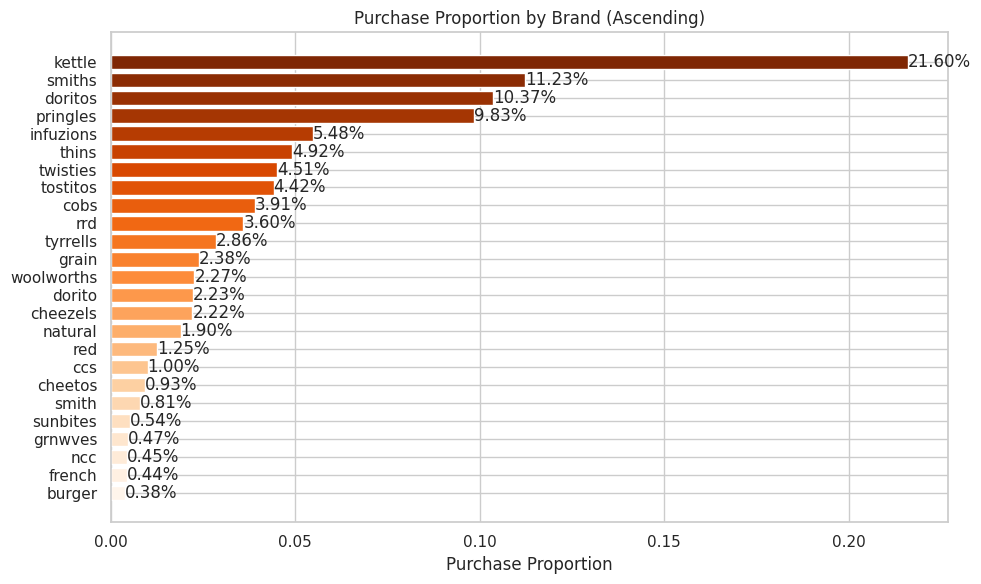

In [696]:
# purchase proportion for each BRAND

brand_sales = df.groupby('BRAND')['TOT_SALES'].sum()
brand_proportions = brand_sales / brand_sales.sum()
brand_proportions_sorted = brand_proportions.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(brand_proportions_sorted.index, brand_proportions_sorted.values, color=[plt.cm.Oranges(i) for i in np.linspace(0, 1, len(brand_proportions_sorted))])

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2, f'{width:.2%}', ha='left', va='center')

plt.xlabel('Purchase Proportion')
plt.title('Purchase Proportion by Brand (Ascending)')
plt.tight_layout()
plt.show()


1. Kettle stands out as the most popular brand with the highest purchase proportion, suggesting a strong preference for its chips.
2. Smiths and Doritos also demonstrate significant purchase proportions followed by Pringles.